# Uncertainty Quantification & Error Analysis

While point estimates for redshift are helpful, many astronomical studies need reliable uncertainty measurements. In this notebook, we use Quantile Regression to generate confidence intervals. We will check if these intervals are well-calibrated and see how uncertainty scales with observational noise or changes in difficult color regions.

In [1]:
import numpy as np
import pandas as pd
import utils
import pickle
from matplotlib import pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor

with open('data/dataset_clean.pkl', 'rb') as file:
    X_train, X_val, X_test, y_train, y_val, y_test = pickle.load(file)['retval']

with open('data/full_dataset_clean.pkl', 'rb') as file:
    df_full = pickle.load(file)
    
i_mag_val = df_full.loc[X_val.index, 'modelMag_i']
i_mag_err = df_full.loc[X_val.index, 'modelMagErr_i']

In [2]:
# Initialize and fit the RF model
rf_model = RandomForestRegressor(max_depth=15, n_estimators=300, max_features=2, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Initialize and fit the GB model
gb_model = HistGradientBoostingRegressor(learning_rate=0.1, max_iter=200, max_depth=20, random_state=42)
gb_model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",200
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",20
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255


### 1.2 Validation Set Evaluation

We generate deterministic point predictions for the validation dataset to allow for direct comparisons later when navigating degenerate color regions.

In [3]:
# Make predictions on the validation set using both models
z_pred_val_rf = rf_model.predict(X_val)
z_pred_val_gb = gb_model.predict(X_val)

## 1. Quantile Regression
### 1.1 Initialization and Training

By substituting the standard MSE loss function with the quantile loss, we train Gradient Boosting models to predict arbitrary quantiles. We extract the 5th, 16th, 50th (median), 84th, and 95th percentiles to form standard 68% and 90% confidence intervals.

In [4]:
models = {}
preds = {}

# Define the quantiles
quantiles = [0.05, 0.16, 0.5, 0.84, 0.95]

for q in quantiles:
    # Initialize and fit each quantile model
    gbr_q = HistGradientBoostingRegressor(loss='quantile', quantile=q, learning_rate=0.1, max_depth=20, max_iter=200, random_state=42)
    gbr_q.fit(X_train, y_train)

    # Make predictions on the validation set
    preds[q] = gbr_q.predict(X_val)

    # Save the model
    models[q] = gbr_q

### 1.2 Validation Set Evaluation (Median)

The median (50th percentile) serves as our central point prediction. We evaluate it against true validation redshifts to ensure optimizing for quantile loss hasn't degraded fundamental predictive accuracy.

In [5]:
# Get the median predictions
q50_preds = preds[0.5]

# Print metrics
print( "-" * 4, f"Validation Dataset Metrics", "-" * 4)
utils.metrics(q50_preds, y_val)

---- Validation Dataset Metrics ----
Outlier Fraction: 0.0266497077617274
Bias:             -0.0009183497334783
NMAD:             0.0159354307958292


### 1.3 Test Set Evaluation (Median)

We run a final test set evaluation by combining the training and validation datasets and fitting a new quantile regressor strictly targeted at the median. This gives us finalized, unbiased point-estimation metrics for this architecture.

In [6]:
print("=" * 36)
print("FINAL TEST SET EVALUATION (Quantile Regression)")
print("Using Hyperparameters: ")
print("{'loss': 'quantile', 'quantile': 0.5, 'learning_rate': 0.1, 'max_depth': 20, 'max_iter': 200}")
print("=" * 36 + "\n")

# Combine train and val data for final testing
X_train_combined = np.vstack((X_train, X_val))
y_train_combined = np.concatenate((y_train, y_val))

# Get the median quantile model and re-fit on the new training set
gbr_q50_final = models[0.5]
gbr_q50_final.fit(np.array(X_train_combined), np.array(y_train_combined))

# Make predictions on the test set
z_pred_test_q50 = gbr_q50_final.predict(np.array(X_test))

# Print metrics
print( "-" * 7, f"Test Dataset Metrics", "-" * 7)
utils.metrics(z_pred_test_q50, y_test)

FINAL TEST SET EVALUATION (Quantile Regression)
Using Hyperparameters: 
{'loss': 'quantile', 'quantile': 0.5, 'learning_rate': 0.1, 'max_depth': 20, 'max_iter': 200}

------- Test Dataset Metrics -------
Outlier Fraction: 0.0261850924654769
Bias:             -0.0009628730522961
NMAD:             0.0158030348444242


## 2. Uncertainty Diagnostics & Calibration
### 2.1 Interval Visualization and Quantile Diagnostics

Statistical calibration means our predicted confidence intervals accurately reflect real-world frequencies. We first check for quantile crossings to ensure our regressor maintains logical ordering. Then, we map the predicted 68% and 95% interval bounds against the true spectroscopic redshifts to visually confirm that uncertainty scales appropriately.

Galaxies with quantile crossing: 182/99063 (0.18%)



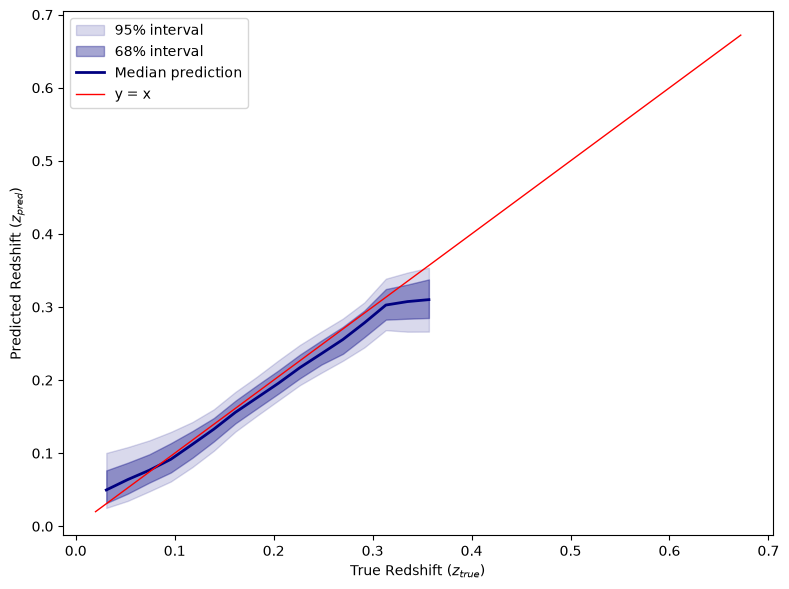

In [7]:
# Creating a 2D array of predictions with each column being a specific quantile
preds_matrix = np.column_stack([preds[q] for q in quantiles])

# Find data points for whom quantile crossing occured
# (a lower quantile having a higher prediction than the bigger quantile)
quantile_crossing = np.all(np.diff(preds_matrix, axis=1) >= 0, axis=1)
n_crossed = (~quantile_crossing).sum()
print(f"Galaxies with quantile crossing: {n_crossed}/{len(quantile_crossing)} ({(n_crossed / len(quantile_crossing) * 100):.2f}%)\n")

# Create graph plotting true vs. predicted redshift with uncertainties
z_true = y_val
n_bins = 30
bin_edges = np.linspace(z_true.min(), z_true.max(), n_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Create lines and intervals to plot
median_line, q16_line, q84_line, q05_line, q95_line = [np.full(n_bins, np.nan) for _ in range(5)]
for i in range(n_bins):
    mask = (z_true >= bin_edges[i]) & (z_true < bin_edges[i + 1])
    if mask.sum() >= 10:
        median_line[i] = np.median(preds_matrix[mask, 2])
        q16_line[i] = np.median(preds_matrix[mask, 1]) 
        q84_line[i] = np.median(preds_matrix[mask, 3]) 
        q05_line[i] = np.median(preds_matrix[mask, 0]) 
        q95_line[i] = np.median(preds_matrix[mask, 4]) 

# Plot the graph
fig, ax = plt.subplots(figsize=(8, 6))
ax.fill_between(bin_centers, q05_line, q95_line, color='navy', alpha=0.15, label='95% interval')
ax.fill_between(bin_centers, q16_line, q84_line, color='navy', alpha=0.35, label='68% interval')
ax.plot(bin_centers, median_line, color='navy', linewidth=2, label='Median prediction')
ax.plot([z_true.min(), z_true.max()], [z_true.min(), z_true.max()], 'r-', linewidth=1, label='y = x')
ax.set_xlabel('True Redshift ($z_{true}$)')
ax.set_ylabel('Predicted Redshift ($z_{pred}$)')
ax.legend()
plt.tight_layout()
plt.show()

### 2.2 Empirical Coverage Evaluation

A perfectly calibrated model captures the true redshift exactly 68% of the time within its 68% confidence interval on unseen data. We calculate this coverage across the entire probability distribution from 10% to 90%. The deviation bar plot highlights exactly how far the empirical coverage strays from perfect calibration at each confidence level.

Empirical Coverage (68% Interval): 0.6748
Empirical Coverage (90% Interval): 0.8930



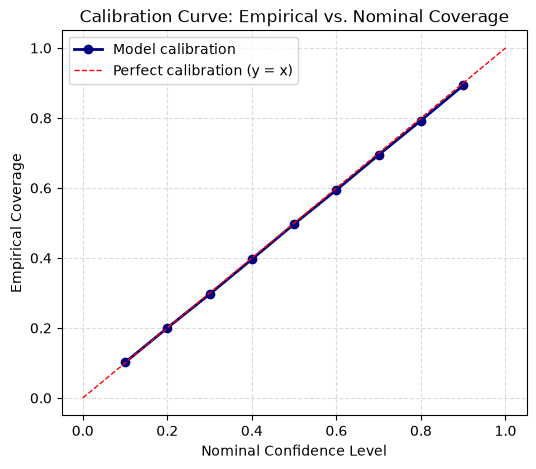

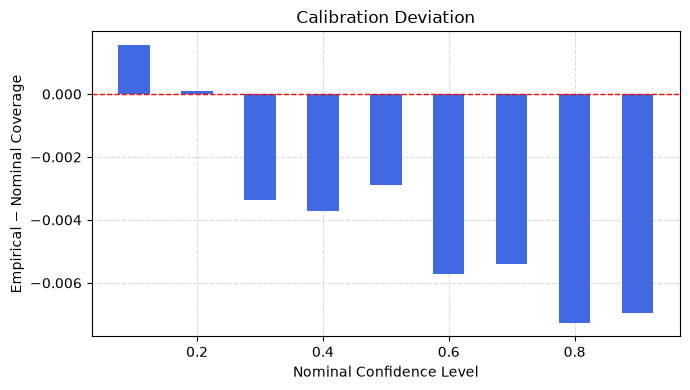

In [8]:
# Check calibration by finding empirical coverage
empirical_coverage_68 = np.mean((y_val >= preds[0.16]) & (y_val <= preds[0.84]))
empirical_coverage_90 = np.mean((y_val >= preds[0.05]) & (y_val <= preds[0.95]))
print(f"Empirical Coverage (68% Interval): {empirical_coverage_68:.4f}")
print(f"Empirical Coverage (90% Interval): {empirical_coverage_90:.4f}\n")

# Building the empirical coverages for confidence levels from 0.1 to 0.9
confidence_levels = np.arange(0.1, 1.0, 0.1)
empirical_coverages = []

for conf in confidence_levels:
    lower_q = (1 - conf) / 2
    upper_q = 1 - lower_q

    # Initialize two models; one for lower quartile (lower_q), one for upper quartile (upper_q)
    gbr_lower_q = HistGradientBoostingRegressor(loss='quantile', quantile=lower_q, learning_rate=0.1, max_depth=20, max_iter=200, random_state=42)
    gbr_upper_q = HistGradientBoostingRegressor(loss='quantile', quantile=upper_q, learning_rate=0.1, max_depth=20, max_iter=200, random_state=42)

    # Train them
    gbr_lower_q.fit(X_train, y_train)
    gbr_upper_q.fit(X_train, y_train)

    # Model prediction
    lower_q_pred = gbr_lower_q.predict(X_val)
    upper_q_pred = gbr_upper_q.predict(X_val)

    # Add to array
    empirical_coverages.append(np.mean((y_val >= lower_q_pred) & (y_val <= upper_q_pred)))

# Plot the calibration curve
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(confidence_levels, empirical_coverages, marker='o', color='navy', linewidth=2, label='Model calibration')
ax.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Perfect calibration (y = x)')
ax.set_title('Calibration Curve: Empirical vs. Nominal Coverage')
ax.set_xlabel('Nominal Confidence Level')
ax.set_ylabel('Empirical Coverage')
ax.legend()
ax.grid(True, linestyle='--', color='lightgray', alpha=0.8)
plt.show()

# Plot the calibration deviations (difference between empirical and nomial coverage)
fig, ax = plt.subplots(figsize=(7, 4))
difference = np.array(empirical_coverages) - confidence_levels
ax.bar(confidence_levels, difference, width=0.05, color='royalblue')
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.grid(True, linestyle='--', color='lightgray', alpha=0.8)
ax.set_xlabel('Nominal Confidence Level')
ax.set_ylabel('Empirical − Nominal Coverage')
ax.set_title('Calibration Deviation')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### 2.3 Interval Width Analysis

We want to connect uncertainty behavior back to physical and observational causes rather than treating it as a black box. By plotting the 68% interval width against redshift, i-band magnitude, and actual photometric error, we can explicitly verify that fainter, noisier, and more distant objects produce wider confidence bounds.

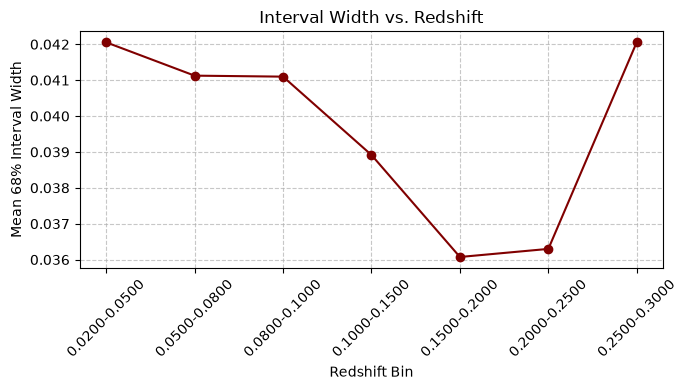

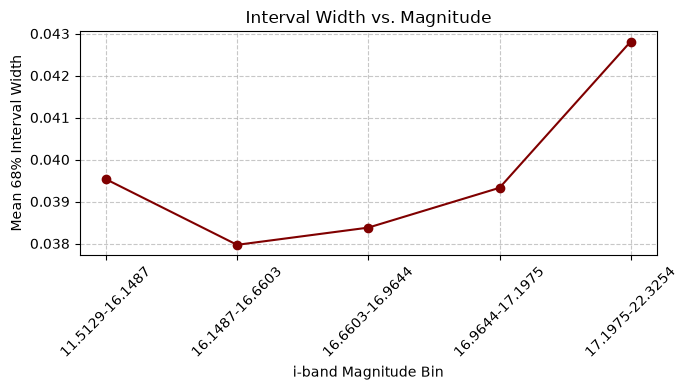

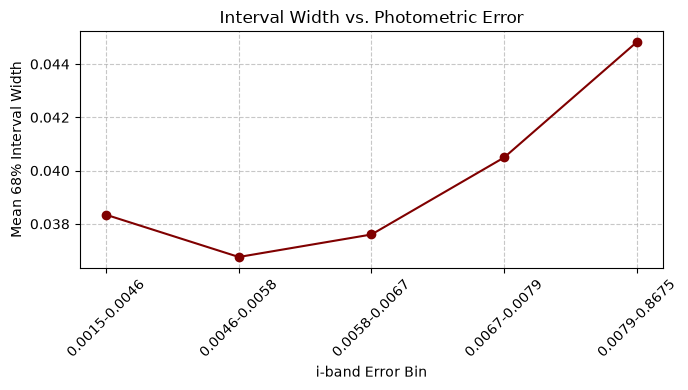

In [9]:
# Get all predictions within the 68% interval
interval_width_68 = preds[0.84] - preds[0.16]

# Create bins for plotting
z_bins = [0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
mag_bins = np.percentile(i_mag_val, [0, 20, 40, 60, 80, 100])
err_bins = np.percentile(i_mag_err, [0, 20, 40, 60, 80, 100])

# Plot Mean 68% Interval Width vs. Redshift
utils.plot_binned_metric(
    feature_array=y_val, 
    bins=z_bins, 
    xlabel='Redshift Bin', 
    ylabel='Mean 68% Interval Width', 
    title='Interval Width vs. Redshift', 
    metric_type='width', 
    width_array=interval_width_68
)

# Plot Mean 68% Interval Width vs. Magnitude
utils.plot_binned_metric(
    feature_array=i_mag_val, 
    bins=mag_bins, 
    xlabel='i-band Magnitude Bin', 
    ylabel='Mean 68% Interval Width', 
    title='Interval Width vs. Magnitude', 
    metric_type='width', 
    width_array=interval_width_68
)

# Plot Mean 68% Interval Width vs. Photometric Error
utils.plot_binned_metric(
    feature_array=i_mag_err, 
    bins=err_bins, 
    xlabel='i-band Error Bin', 
    ylabel='Mean 68% Interval Width', 
    title='Interval Width vs. Photometric Error', 
    metric_type='width', 
    width_array=interval_width_68
)

## 3. Degenerate Regions Assessment

We isolate the validation galaxies falling inside the severely degenerate boundary (`g-r ∈ [0.4, 0.75]`, `r-i ∈ [0.15, 0.35]`) mapped out earlier. Comparing performance in this region against the rest of the sample quantifies how predictive accuracy degrades when fundamental photometric information overlaps.

In [10]:
# Define the degenerate region
degenerate_mask = (
    (X_val['g-r'] > 0.4) & (X_val['g-r'] < 0.75) &
    (X_val['r-i'] > 0.15) & (X_val['r-i'] < 0.35)
)

# Use the mask to compare model performance in the degenerate region vs. the rest of the sample
print("-" * 4, "68% Interval Width: Degenerate Region vs. Rest", "-" * 4)
print(f"Degenerate region (N={degenerate_mask.sum()}):  Mean width = {interval_width_68[degenerate_mask].mean():.6f}")
print(f"Rest of sample (N={(~degenerate_mask).sum()}):  Mean width = {interval_width_68[~degenerate_mask].mean():.6f}\n")

---- 68% Interval Width: Degenerate Region vs. Rest ----
Degenerate region (N=12000):  Mean width = 0.047193
Rest of sample (N=87063):  Mean width = 0.038558

